In [31]:
#instala algumas bibliotecas caso não tenha já instalado
#pip install
!pip install matplotlib setuptools scikit-learn

In [32]:
#importa bibliotecas necessárias
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt

In [33]:
#importa a base com os dados
df = pd.read_csv(r"../data/sample/projeto_1_conversao_imobiliaria.csv", sep=';', encoding='utf-8')

In [34]:
#analise exploratória, data understanding

#mosta as colunas:
print("Cabecalho da base\n")
print(df.head(3))

print("\ninformações sobre o dataset\n")
df.info()

Cabecalho da base

   id_proposta          cpf_hash data_proposta          cidade  uf    regiao  \
0  PROP_000001  CPF_201414_00001    2025-07-14          Santos  SP   Sudeste   
1  PROP_000002  CPF_765822_00002    2025-11-08          Recife  PE  Nordeste   
2  PROP_000003  CPF_479580_00003    2025-07-24  Rio de Janeiro  RJ   Sudeste   

  estado_civil  idade   profissao    canal_origem  ... lead_score_marketing  \
0     Solteiro     37  Empresário  Correspondente  ...                   97   
1       Casado     37  Aposentado  Correspondente  ...                   78   
2     Solteiro     35    Autônomo       Indicação  ...                   52   

   aprovado_pre_analise  valor_parcela_estimado  prazo_meses  \
0                     0                 3023.44          420   
1                     0                 3549.92          360   
2                     1                 2008.26          300   

   taxa_juros_anual  dias_ate_contato  qtd_interacoes_comercial  contratou  \
0       

In [35]:
#analise do alvo:

#faz um groupby dessa coluna e mostra quando tem de cada um:
df["contratou"].value_counts()

#mostra a porcentagem de cada caso dessa coluna

result = df['contratou'].value_counts(normalize=True)


#média das idades que contrataram e a média de prazo

rslt = df.groupby("contratou").agg(

    media_idade = ("idade","mean"),
    prazo_medio = ("prazo_meses","mean")
)
rslt['anos'] = rslt['prazo_medio']/12


print(rslt)
print(result)

           media_idade  prazo_medio       anos
contratou                                     
0            38.970632   331.897106  27.658092
1            37.456716   343.343284  28.611940
contratou
0    0.933
1    0.067
Name: proportion, dtype: float64


In [36]:
#hipoteses
#ve a média de score para cada flag
resultado_1 = df.groupby('contratou')['score_credito'].mean()

#quantidade de contrato e não contratos por região:
df.groupby('regiao')['contratou'].value_counts().sort_values(ascending=False)

# Agrupa por região e calcula a média (conversão) e a contagem (total)
resultado = df.groupby('regiao').agg(
    taxa_conversao=('contratou', 'mean'),
    total_propostas=('contratou', 'count'),
    renda_media=('renda_mensal', 'mean'),
    media_valor_imovel = ('valor_imovel','mean')
).sort_values(by='taxa_conversao', ascending=False)

# Multiplica por 100 apenas a coluna de conversão para ver em %
resultado['taxa_conversao'] = resultado['taxa_conversao'] * 100

#adiciona média geral das quantidades de propsotas
resultado["media_qtd_propostas"] = resultado["total_propostas"].mean()

print(resultado)

print(resultado_1)

              taxa_conversao  total_propostas   renda_media  \
regiao                                                        
Norte               7.854406              522   9336.399387   
Centro-Oeste        6.981132              530  10194.059736   
Sul                 6.824513              718   9743.459220   
Nordeste            6.713427              998   9236.125431   
Sudeste             6.317204             2232   9575.737106   

              media_valor_imovel  media_qtd_propostas  
regiao                                                 
Norte              312103.351494               1000.0  
Centro-Oeste       425361.232377               1000.0  
Sul                415837.402646               1000.0  
Nordeste           329516.610030               1000.0  
Sudeste            417896.765287               1000.0  
contratou
0    569.427010
1    690.271642
Name: score_credito, dtype: float64


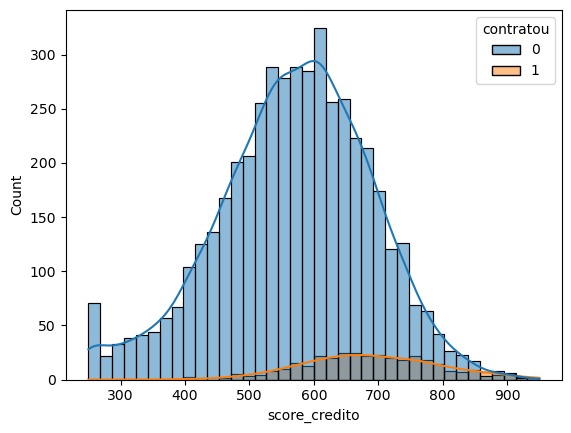

In [37]:
sbn.histplot(data=df, x='score_credito', hue='contratou', kde=True)

plt.show()

<Axes: xlabel='contratou', ylabel='score_credito'>

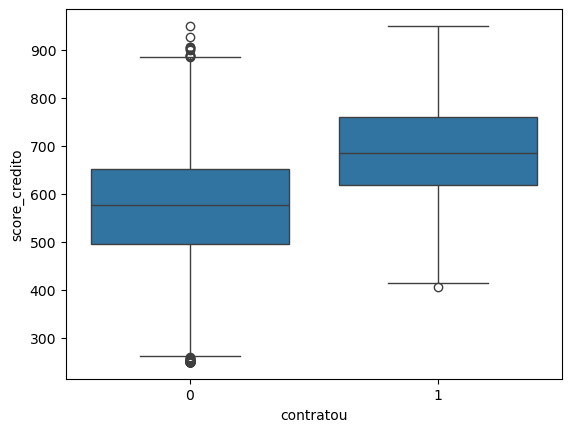

In [38]:
sbn.boxplot(x='contratou', y='score_credito', data=df)

In [39]:
df.corr(numeric_only=True)

,idade,renda_mensal,valor_imovel,valor_financiado,entrada,ltv,score_credito,atrasos_anteriores,divida_total,comprometimento_renda,...,tempo_relacionamento_banco_meses,num_consultas_credito_90d,lead_score_marketing,aprovado_pre_analise,valor_parcela_estimado,prazo_meses,taxa_juros_anual,dias_ate_contato,qtd_interacoes_comercial,contratou
idade,1.000000,-0.043265,-0.014189,-0.007481,-0.024427,0.022452,-0.016233,0.007281,-0.008920,-0.001647,...,0.001466,0.003490,0.002011,-0.017611,0.000211,-0.009055,0.028357,0.004820,0.007209,-0.035935
renda_mensal,-0.043265,1.000000,0.225017,0.145112,0.333392,-0.266070,0.268703,-0.000115,0.429671,0.010302,...,0.002757,0.021543,0.013127,0.175530,0.126605,0.007586,-0.065057,0.001758,-0.003719,0.229598
valor_imovel,-0.014189,0.225017,1.000000,0.962616,0.833437,-0.066283,0.057928,-0.004107,0.098431,0.015413,...,0.015024,-0.023086,0.007539,0.047432,0.931630,-0.017395,-0.034830,-0.022718,-0.001708,0.031248
valor_financiado,-0.007481,0.145112,0.962616,1.000000,0.652592,0.172544,0.023657,0.024201,0.062855,0.014828,...,0.015734,-0.020436,0.010130,0.023677,0.971823,-0.018793,-0.023715,-0.024666,0.006111,0.008927
entrada,-0.024427,0.333392,0.833437,0.652592,1.000000,-0.537427,0.113779,-0.060862,0.147109,0.012864,...,0.009927,-0.022887,0.000424,0.084377,0.623400,-0.010318,-0.049047,-0.013228,-0.017244,0.069197
ltv,0.022452,-0.266070,-0.066283,0.172544,-0.537427,1.000000,-0.124355,0.119686,-0.107739,0.005824,...,-0.006612,0.006900,-0.005601,-0.083706,0.177867,0.001686,0.031665,-0.014723,0.023969,-0.081413
score_credito,-0.016233,0.268703,0.057928,0.023657,0.113779,-0.124355,1.000000,-0.570067,0.101441,-0.002251,...,-0.000654,0.010386,-0.001992,0.767383,-0.021197,0.009987,-0.222265,-0.000273,-0.031337,0.247453
atrasos_anteriores,0.007281,-0.000115,-0.004107,0.024201,-0.060862,0.119686,-0.570067,1.000000,0.010683,0.003838,...,-0.018917,-0.002302,0.002879,-0.438064,0.046077,0.007108,0.109112,-0.011407,0.007290,-0.147389
divida_total,-0.008920,0.429671,0.098431,0.062855,0.147109,-0.107739,0.101441,0.010683,1.000000,0.736429,...,-0.000999,0.004939,0.014203,-0.022742,0.058055,-0.002208,-0.022048,-0.009634,-0.014318,0.079063
comprometimento_renda,-0.001647,0.010302,0.015413,0.014828,0.012864,0.005824,-0.002251,0.003838,0.736429,1.000000,...,-0.010637,0.000061,0.001489,-0.122872,0.017268,-0.002427,0.002556,-0.006434,-0.015427,-0.011744


In [40]:
df.isnull().sum()


id_proposta                            0
cpf_hash                               0
data_proposta                          0
cidade                                 0
uf                                     0
regiao                                 0
estado_civil                           0
idade                                  0
profissao                              0
canal_origem                           0
tipo_imovel                            0
renda_mensal                           0
valor_imovel                           0
valor_financiado                       0
entrada                                0
ltv                                    0
score_credito                          0
atrasos_anteriores                     0
divida_total                           0
comprometimento_renda                  0
possui_fgts                            0
tempo_relacionamento_banco_meses       0
num_consultas_credito_90d              0
lead_score_marketing                   0
aprovado_pre_ana

In [41]:
df.corr(numeric_only=True)['contratou'].sort_values()


atrasos_anteriores                 -0.147389
ltv                                -0.081413
taxa_juros_anual                   -0.052629
dias_ate_contato                   -0.039625
idade                              -0.035935
comprometimento_renda              -0.011744
valor_parcela_estimado             -0.004459
num_consultas_credito_90d           0.004085
valor_financiado                    0.008927
tempo_relacionamento_banco_meses    0.017279
valor_imovel                        0.031248
prazo_meses                         0.042757
qtd_interacoes_comercial            0.048821
possui_fgts                         0.052109
lead_score_marketing                0.066123
entrada                             0.069197
divida_total                        0.079063
aprovado_pre_analise                0.176181
renda_mensal                        0.229598
score_credito                       0.247453
contratou                           1.000000
Name: contratou, dtype: float64

In [42]:
print("INICIANDO A CONSTRUÇÂO DO MODELO: DATA PREPARATION")

INICIANDO A CONSTRUÇÂO DO MODELO: DATA PREPARATION


In [43]:
#importa bibliotecas importates para o modelo:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [44]:
ids = df['id_proposta']

#alvo
Y=df["contratou"]

#features:
X= df[
    [
        "score_credito",
        "valor_imovel",
        "renda_mensal",
        "valor_financiado",
        "comprometimento_renda",
        "divida_total",
        "possui_fgts",
        "lead_score_marketing",
        "entrada"
    ]
]

#divide dados de treino e de teste
X_treino,X_teste, Y_treino,Y_teste,ids_treino,ids_teste = train_test_split(
    X,
    Y,
    ids,
    test_size = 0.2,
    stratify=Y,
    random_state=42
    
)
#Aprende scaler de treino
scaler.fit(X_treino)

#transforma treino
X_treino = scaler.transform(X_treino)

X_teste = scaler.transform(X_teste)

#treina modelo:
modelo = LogisticRegression()
modelo.fit(X_treino,Y_treino)

#fazendo as previsoes:
previsoes_m1 = modelo.predict(X_teste)
previsoes_m2 = modelo.predict_proba(X_teste)[:,1]


#avaliando matriz de confusão:
print("--- Matriz de Confusão Predict ---")
print(confusion_matrix(Y_teste,previsoes_m1))

print("\n--- Relatório de Classificação Predict ---")
print(classification_report(Y_teste, previsoes_m1))

print("\n-------------------------------------------")

#avaliando matriz de confusãocom diversos Threshold:
for threshold in [0.50, 0.40, 0.30, 0.20, 0.10]:
    print(f"\nTestando com o Threshold:",threshold)
    m2= (previsoes_m2 >= threshold).astype(int)
    
    print("\n--- Matriz de Confusão predict_proba ---")
    print(confusion_matrix(Y_teste,m2))
    
    print("\n--- Relatório de Classificação predict_proba ---")
    print(classification_report(Y_teste, m2))
    


--- Matriz de Confusão Predict ---
[[925   8]
 [ 61   6]]

--- Relatório de Classificação Predict ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       933
           1       0.43      0.09      0.15        67

    accuracy                           0.93      1000
   macro avg       0.68      0.54      0.56      1000
weighted avg       0.90      0.93      0.91      1000


-------------------------------------------

Testando com o Threshold: 0.5

--- Matriz de Confusão predict_proba ---
[[925   8]
 [ 61   6]]

--- Relatório de Classificação predict_proba ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       933
           1       0.43      0.09      0.15        67

    accuracy                           0.93      1000
   macro avg       0.68      0.54      0.56      1000
weighted avg       0.90      0.93      0.91      1000


Testando com o Threshold: 0.4

--- Matriz de Confusã

In [45]:
print("Estudo Do que o medelo aprendeu !!!!")

Estudo Do que o medelo aprendeu !!!!


In [50]:
df_result = pd.DataFrame({
    'id_proposta': ids_teste,
    'real': Y_teste,
    'probabilidade': previsoes_m2
})

df_reuslt = df_result.sort_values(
    by='probabilidade',
    ascending=False
)

df_reuslt.to_csv(
    r'../resultado/resultados_modelo.csv',
    index=False,
    encoding='utf-8',
    sep=';',
    decimal=',')

print("Arquivo CSV exportado com sucesso!")
print(df_resultado.head())


Arquivo CSV exportado com sucesso!
      id_proposta  real  probabilidade
2743  PROP_002744     1       0.794099
3578  PROP_003579     0       0.778397
242   PROP_000243     1       0.723754
300   PROP_000301     1       0.711092
2522  PROP_002523     1       0.691034


In [52]:
#Analise de coeficientes:
coenficientes = pd.DataFrame({
    'variavel':X.columns,
    'coeficiente':modelo.coef_[0]
})

coenficientes = coenficientes.sort_values(
    by='coeficiente',
    ascending=False
)

coenficientes.to_csv(
    r'../resultado/analise_coeficiente_modelo.csv',
    index=False,
    encoding='utf-8',
    sep=';',
    decimal=',')

print("Arquivo CSV exportado com sucesso!")
print(coenficientes.head())


Arquivo CSV exportado com sucesso!
               variavel  coeficiente
0         score_credito     1.069875
7  lead_score_marketing     0.331293
2          renda_mensal     0.330736
6           possui_fgts     0.286850
8               entrada     0.074982


In [55]:
#gerando Curva RoC e AUC do meldo:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(Y_teste,previsoes_m2)

print("AUC: ", auc)


AUC:  0.7952040440882404


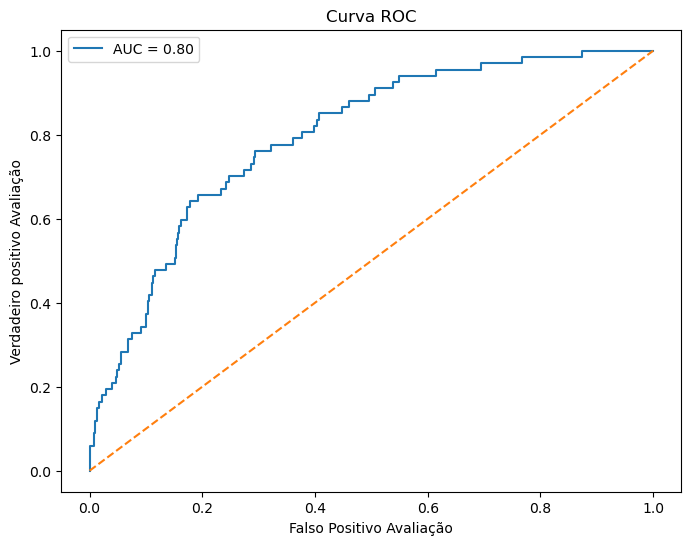

In [56]:
#curva roc
# thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

fpr, tpr, thresholds = roc_curve(Y_teste,previsoes_m2)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,label=f'AUC = {auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('Falso Positivo Avaliação')
plt.ylabel('Verdadeiro positivo Avaliação')

plt.title('Curva ROC')

plt.legend()

plt.show()